## EDA for the Human Eval Dataset 

https://github.com/openai/human-eval/


### Imports

In [24]:
import os 
import json
import pandas as pd

### Loading Data

In [25]:
with open('../../irat/data/human_eval.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]


In [26]:
# Convert list of dictionaries to pandas dataframe
df = pd.DataFrame(data)
print(f"DataFrame shape: {df.shape}")
df.head()


DataFrame shape: (164, 5)


,task_id,prompt,entry_point,canonical_solution,test
0,HumanEval/0,from typing import List\n\n\ndef has_close_ele...,has_close_elements,"for idx, elem in enumerate(numbers):\n ...","\n\nMETADATA = {\n 'author': 'jt',\n 'da..."
1,HumanEval/1,from typing import List\n\n\ndef separate_pare...,separate_paren_groups,result = []\n current_string = []\n ...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da..."
2,HumanEval/2,\n\ndef truncate_number(number: float) -> floa...,truncate_number,return number % 1.0\n,"\n\nMETADATA = {\n 'author': 'jt',\n 'da..."
3,HumanEval/3,from typing import List\n\n\ndef below_zero(op...,below_zero,balance = 0\n\n for op in operations:\n...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da..."
4,HumanEval/4,from typing import List\n\n\ndef mean_absolute...,mean_absolute_deviation,mean = sum(numbers) / len(numbers)\n re...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da..."


In [27]:
pd2 = pd.read_excel("analysis/human-eval-analysis.xls")

In [28]:
pd2.head()

,TASK_ID,type,extra
0,HumanEval/0,nested_loops,NaN
1,HumanEval/1,string_parsing,NaN
2,HumanEval/2,math,NaN
3,HumanEval/3,math,NaN
4,HumanEval/4,math,NaN


In [42]:
type_counts = pd2['type'].dropna().value_counts()
type_counts

type
lists                53
math                 45
strings              30
problem_solving      22
string_parsing        8
nested_loops          2
sorting               2
encoding_decoding     1
dictionaries          1
Name: count, dtype: int64

In [43]:
extra_counts =pd2['extra'].dropna().value_counts()
extra_counts

extra
math                 13
sorting               9
filtering             8
lists                 7
strings               6
palindrome            5
encoding_decoding     4
nested_loops          3
substrings            2
string_parsing        2
boolean_logic         1
sequence              1
distance              1
matrix                1
date_time             1
Name: count, dtype: int64

In [46]:
histogram = {}

for category, count in type_counts.items():
    histogram[category] = count

for category, count in extra_counts.items():
    if category not in histogram:
        histogram[category] = count
    else:
        histogram[category] += count


In [58]:
all_categories = pd.Series(histogram)[0:4]

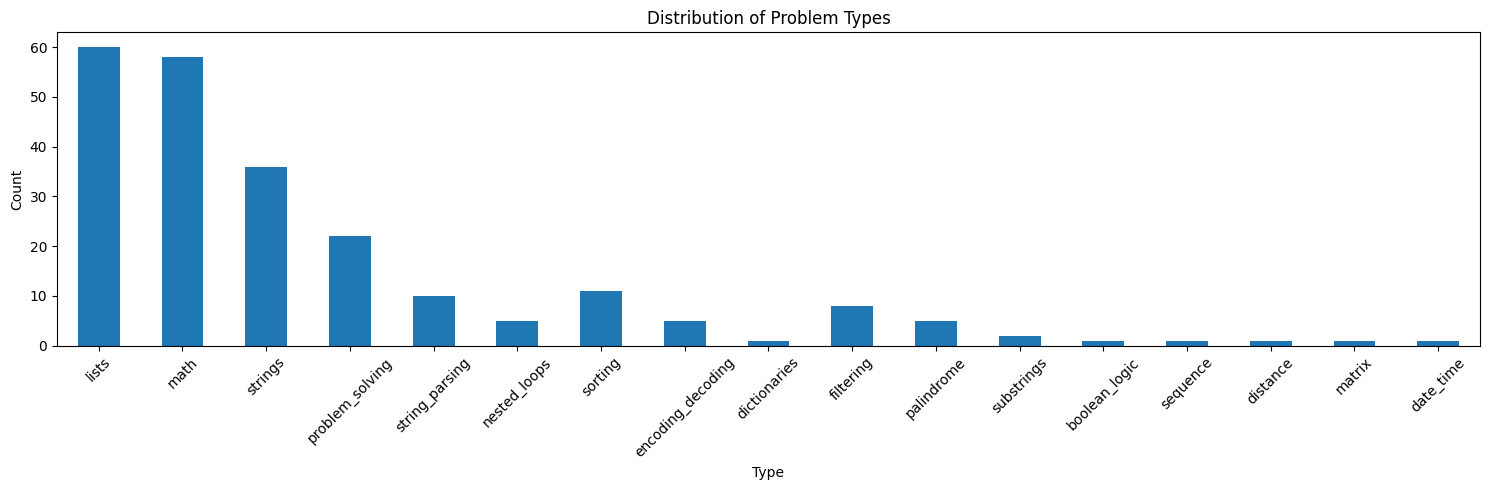

In [56]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 5))

all_categories.plot(kind='bar', ax=ax1)
ax1.set_title('Distribution of Problem Types')
ax1.set_xlabel('Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
